# CNN sobre MNIST con TensorFlow/Keras

## Objetivo

Construir una CNN pequeña y reproducible para MNIST, explicando convolución, filtros, pooling y clasificación multiclase. El notebook utiliza validation para callbacks y restaura el mejor checkpoint antes de evaluar test una sola vez.

> Dependencias: `requirements/common.txt` y `requirements/tensorflow.txt`. No se instalan paquetes durante la ejecución.

## 1. Configuración

`RUN_MODE=fast` es un smoke test no publicable; `RUN_MODE=full` produce resultados definitivos si finaliza y valida correctamente.

In [1]:
import gzip
import json
import os
import platform
import random
import struct
import subprocess
import sys
import time
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

RUN_MODE = os.getenv("RUN_MODE", "full").lower()
if RUN_MODE not in {"fast", "full"}:
    raise ValueError("RUN_MODE debe ser 'fast' o 'full'")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


def localizar_tema2():
    cwd = Path.cwd().resolve()
    for candidato in [cwd, cwd / "tema-02-machine-learning", *cwd.parents]:
        if candidato.name == "tema-02-machine-learning" and (candidato / ".tema2-root").exists():
            return candidato
    raise FileNotFoundError("No se pudo localizar tema-02-machine-learning")


TEMA2_ROOT = localizar_tema2()
DATA_DIR = TEMA2_ROOT / ".data" / "mnist"
RESULTS_ROOT = TEMA2_ROOT / "03-redes-multicapa-convolucionales-vision" / "results" / "02_cnn_mnist_keras"
RUN_DIR = RESULTS_ROOT / "experiments" / RUN_MODE / "mnist_cnn"
CHECKPOINT_DIR = RESULTS_ROOT / "checkpoints"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PUBLISHABLE = RUN_MODE == "full"

devices = tf.config.list_physical_devices()
device = "gpu" if any(item.device_type == "GPU" for item in devices) else "cpu"
print(f"RUN_MODE={RUN_MODE} | publishable={str(PUBLISHABLE).lower()}")
print(f"TensorFlow={tf.__version__} | Keras={keras.__version__ if hasattr(keras, '__version__') else '2.15'} | dispositivo={device}")

RUN_MODE=full | publishable=true
TensorFlow=2.15.1 | Keras=2.15 | dispositivo=cpu


## 2. Dataset, normalización y particiones

El train oficial se divide estratificadamente en train y validation. Las imágenes se normalizan a `[0,1]` y reciben un canal explícito. Test queda aislado hasta el final.

In [2]:
URLS = {
    "train-images-idx3-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}


def descargar(nombre, url):
    destino = DATA_DIR / nombre
    if not destino.exists():
        temporal = destino.with_suffix(destino.suffix + ".tmp")
        urllib.request.urlretrieve(url, temporal)
        temporal.replace(destino)
    return destino


def leer_imagenes(path):
    with gzip.open(path, "rb") as stream:
        magic, n, rows, cols = struct.unpack(">IIII", stream.read(16))
        if magic != 2051:
            raise ValueError("Formato IDX inválido")
        return np.frombuffer(stream.read(), dtype=np.uint8).reshape(n, rows, cols)


def leer_etiquetas(path):
    with gzip.open(path, "rb") as stream:
        magic, n = struct.unpack(">II", stream.read(8))
        if magic != 2049:
            raise ValueError("Formato IDX inválido")
        values = np.frombuffer(stream.read(), dtype=np.uint8)
    return values


paths = {name: descargar(name, url) for name, url in URLS.items()}
X_all = leer_imagenes(paths["train-images-idx3-ubyte.gz"])
y_all = leer_etiquetas(paths["train-labels-idx1-ubyte.gz"])
X_test = leer_imagenes(paths["t10k-images-idx3-ubyte.gz"])
y_test = leer_etiquetas(paths["t10k-labels-idx1-ubyte.gz"])
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED
)


def limitar(X, y, n, seed):
    if n is None or len(y) <= n:
        return X, y
    X_keep, _, y_keep, _ = train_test_split(
        X, y, train_size=n, stratify=y, random_state=seed
    )
    return X_keep, y_keep


if RUN_MODE == "fast":
    X_train, y_train = limitar(X_train, y_train, 5000, SEED)
    X_val, y_val = limitar(X_val, y_val, 1200, SEED + 1)
    X_test, y_test = limitar(X_test, y_test, 1500, SEED + 2)

normalize = lambda X: (X.astype("float32") / 255.0)[..., np.newaxis]
X_train_n, X_val_n, X_test_n = map(normalize, [X_train, X_val, X_test])
print(f"Train={len(y_train):,} | Validation={len(y_val):,} | Test={len(y_test):,}")

Train=51,000 | Validation=9,000 | Test=10,000


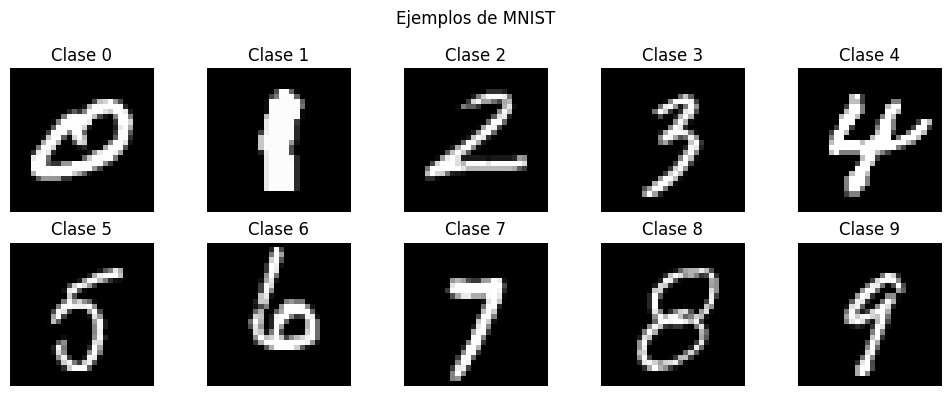

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == digit)[0]
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(f"Clase {digit}")
    ax.axis("off")
plt.suptitle("Ejemplos de MNIST")
plt.tight_layout()
plt.show()

## 3. Arquitectura CNN

- `Conv2D`: aprende filtros locales.
- Kernel 3×3: ventana espacial pequeña.
- Padding `same`: conserva tamaño.
- `MaxPooling2D`: reduce resolución y aporta tolerancia local.
- `BatchNormalization` y `Dropout`: estabilización y regularización.
- La última capa entrega diez probabilidades mediante softmax; la pérdida usa etiquetas enteras con `sparse_categorical_crossentropy`.

In [4]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(10, activation="softmax"),
], name="cnn_mnist_keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
parameter_count = model.count_params()
model.summary()

Model: "cnn_mnist_keras"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 28, 28, 32)        320       


 batch_normalization (Batch  (None, 28, 28, 32)        128       


...

 dense_1 (Dense)             (None, 10)                1290      


Total params: 422026 (1.61 MB)


Trainable params: 421834 (1.61 MB)


Non-trainable params: 192 (768.00 Byte)


_________________________________________________________________


## 4. Callbacks y entrenamiento

Los tres callbacks monitorizan `val_loss`: `ModelCheckpoint` guarda el mejor modelo, `EarlyStopping` evita sobreentrenamiento y `ReduceLROnPlateau` reduce el learning rate. Ninguno consulta test.

In [5]:
checkpoint_path = str(CHECKPOINT_DIR / f"cnn_mnist_{RUN_MODE}.keras")
callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min",
        save_best_only=True, verbose=0,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min", patience=3,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", mode="min", factor=0.5,
        patience=1, min_lr=1e-5, verbose=1,
    ),
]
epochs = 2 if RUN_MODE == "fast" else 20
start = time.perf_counter()
history_object = model.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=epochs, batch_size=128,
    callbacks=callbacks, verbose=2,
)
training_seconds = time.perf_counter() - start
model = keras.models.load_model(checkpoint_path)
history = pd.DataFrame(history_object.history)
history.insert(0, "epoch", np.arange(1, len(history) + 1))
best_epoch = int(history["val_loss"].idxmin() + 1)
print(f"Mejor época={best_epoch} | tiempo={training_seconds:.2f} s")

Epoch 1/20


399/399 - 19s - loss: 0.2638 - accuracy: 0.9216 - val_loss: 0.4385 - val_accuracy: 0.8426 - lr: 0.0010 - 19s/epoch - 47ms/step


Epoch 2/20


399/399 - 16s - loss: 0.0912 - accuracy: 0.9725 - val_loss: 0.0575 - val_accuracy: 0.9826 - lr: 0.0010 - 16s/epoch - 39ms/step


Epoch 3/20


...

Restoring model weights from the end of the best epoch: 10.



Epoch 13: ReduceLROnPlateau reducing learning rate to 1e-05.


399/399 - 16s - loss: 0.0138 - accuracy: 0.9951 - val_loss: 0.0355 - val_accuracy: 0.9910 - lr: 1.5625e-05 - 16s/epoch - 40ms/step


Epoch 13: early stopping


Mejor época=10 | tiempo=210.15 s


## 5. Evaluación final de test

Tras restaurar el mejor checkpoint se evalúa test una sola vez y se generan métricas por clase, curvas y ejemplos de error.

In [6]:
probabilities = model.predict(X_test_n, batch_size=256, verbose=0)
y_pred = probabilities.argmax(axis=1)
report = pd.DataFrame(classification_report(
    y_test, y_pred, output_dict=True, zero_division=0
)).T
metrics = {
    "experiment_id": "mnist_cnn",
    "task": "multiclass_classification",
    "classes": [str(i) for i in range(10)],
    "train_samples": len(y_train),
    "validation_samples": len(y_val),
    "test_samples": len(y_test),
    "epochs_or_iterations_completed": len(history),
    "best_epoch_or_iteration": best_epoch,
    "parameters": parameter_count,
    "training_seconds": training_seconds,
    "best_validation_accuracy": float(history.loc[best_epoch - 1, "val_accuracy"]),
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "test_recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "test_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "test_macro_precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "test_macro_recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "test_macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "test_balanced_accuracy": recall_score(y_test, y_pred, average="macro"),
    "test_specificity": None,
}
(RUN_DIR / "metrics.json").write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8"
)
history.to_csv(RUN_DIR / "training_history.csv", index=False)
report.to_csv(RUN_DIR / "classification_report.csv")
display(pd.Series(metrics, name="valor").to_frame())
display(report)

,valor
experiment_id,mnist_cnn
task,multiclass_classification
classes,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
train_samples,51000
validation_samples,9000
test_samples,10000
epochs_or_iterations_completed,13
best_epoch_or_iteration,10
parameters,422026
training_seconds,210.149463


,precision,recall,f1-score,support
0,0.994908,0.996939,0.995923,980.0000
1,0.994728,0.997357,0.996040,1135.0000
2,0.991321,0.996124,0.993717,1032.0000
3,0.992087,0.993069,0.992578,1010.0000
4,0.990872,0.994908,0.992886,982.0000
5,0.987751,0.994395,0.991061,892.0000
6,0.998945,0.988518,0.993704,958.0000
7,0.990291,0.992218,0.991254,1028.0000
8,0.991795,0.992813,0.992304,974.0000
9,0.994975,0.981169,0.988024,1009.0000


In [7]:
def guardar(fig, name):
    fig.savefig(RUN_DIR / name, dpi=140, bbox_inches="tight")
    plt.close(fig)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.epoch, history.loss, label="train")
axes[0].plot(history.epoch, history.val_loss, label="validation")
axes[0].axvline(best_epoch, ls="--", color="gray", label="mejor época")
axes[0].set(title="Pérdida", xlabel="Época", ylabel="Loss")
axes[0].legend()
axes[1].plot(history.epoch, history.accuracy, label="train")
axes[1].plot(history.epoch, history.val_accuracy, label="validation")
axes[1].set(title="Accuracy", xlabel="Época", ylabel="Accuracy")
axes[1].legend()
fig.tight_layout()
guardar(fig, "learning_curves.png")

cm = confusion_matrix(y_test, y_pred, labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(
    cmap="Blues", ax=ax, values_format="d"
)
ax.set_title("Matriz de confusión — CNN MNIST")
guardar(fig, "confusion_matrix.png")


def ejemplos(indices, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(11, 5))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, idx in zip(axes.ravel(), indices[:10]):
        ax.imshow(X_test[idx], cmap="gray")
        ax.set_title(f"Real={y_test[idx]} | Pred={y_pred[idx]}")
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    guardar(fig, filename)


ejemplos(np.flatnonzero(y_test == y_pred), "Predicciones correctas", "sample_predictions.png")
ejemplos(np.flatnonzero(y_test != y_pred), "Ejemplos mal clasificados", "misclassified_examples.png")

## 6. Interpretación

La CNN preserva estructura espacial y reutiliza filtros, a diferencia del MLP. Overfitting se observa cuando training continúa mejorando y validation empeora; los callbacks actúan sobre validation para limitarlo. Las confusiones deben estudiarse por clase y mediante ejemplos concretos.

In [8]:
try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=TEMA2_ROOT.parent,
        capture_output=True, text=True, check=True,
    ).stdout.strip()
except Exception:
    git_commit = "UNAVAILABLE"

summary = {
    "notebook_id": "03-02",
    "source_notebook": "2_convolutional_neural_network_model.ipynb",
    "canonical_notebook": "02_cnn_mnist_keras.ipynb",
    "module": "03-redes-multicapa-convolucionales-vision",
    "status": "COMPLETED",
    "run_mode": RUN_MODE,
    "publishable": PUBLISHABLE,
    "seed": SEED,
    "device": device,
    "frameworks": ["tensorflow", "keras"],
    "dataset": "MNIST",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "experiments": ["mnist_cnn"],
}
summary_name = "run_summary.json" if RUN_MODE == "full" else "run_summary.fast.json"
(RESULTS_ROOT / summary_name).write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
environment_name = "environment.txt" if RUN_MODE == "full" else "environment.fast.txt"
(RESULTS_ROOT / environment_name).write_text("\n".join([
    f"platform={platform.platform()}", f"python={sys.version}",
    f"tensorflow={tf.__version__}", f"numpy={np.__version__}",
    f"scikit-learn={sklearn.__version__}", f"device={device}",
]), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "notebook_id": "03-02",
  "source_notebook": "2_convolutional_neural_network_model.ipynb",
  "canonical_notebook": "02_cnn_mnist_keras.ipynb",
  "module": "03-redes-multicapa-convolucionales-vision",
  "status": "COMPLETED",
  "run_mode": "full",
  "publishable": true,
  "seed": 42,
  "device": "cpu",
  "frameworks": [
    "tensorflow",
    "keras"
  ],
  "dataset": "MNIST",
  "run_timestamp_utc": "2026-06-24T03:03:08.719914+00:00",
  "git_commit": "4f941bc039a0588f28bf035acabdb1870dcb709e",
  "experiments": [
    "mnist_cnn"
  ]
}


## 7. Conclusiones

### Técnica

La CNN explota patrones locales y selecciona su mejor estado mediante validation. El checkpoint, early stopping y scheduler monitorizan una señal coherente; test permanece aislado.

### Ejecutiva

Las CNN son adecuadas cuando la posición y vecindad contienen información. Conceptualmente, Marina del Sol podría usarlas para inspección visual o clasificación de imágenes operativas, siempre con datos gobernados, evaluación de riesgos, monitorización y revisión humana. Este notebook académico no está listo para producción.